# BANKING77 Deep Learning Baseline

This notebook implements a PyTorch-based deep learning baseline
for the 77-class customer ticket classification task.

Pipeline:

Text
→ Tokenization
→ Vocabulary
→ Integer Encoding
→ Padding
→ Embedding
→ TextCNN
→ 77-class Classification

In [1]:
# Cell 1：基础环境

from pathlib import Path
import random
import numpy as np
import pandas as pd

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.8.0+cu128
CUDA available: True


In [2]:
# Cell 2：固定随机种子

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
# Cell 3：选择训练设备

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cuda


In [4]:
# Cell 4：项目路径

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

print("Project root:")
print(PROJECT_ROOT.resolve())

print()

print("Processed data directory:")
print(PROCESSED_DATA_DIR.resolve())

Project root:
C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing

Processed data directory:
C:\Users\LYG Y9000x\OneDrive\Desktop\lyg master ai project\customer-ticket-routing\data\processed


In [5]:
# Cell 5：加载与Version 1完全相同的数据划分

TRAIN_PATH = (
    PROCESSED_DATA_DIR
    / "train_77.csv"
)

VALIDATION_PATH = (
    PROCESSED_DATA_DIR
    / "validation_77.csv"
)

TEST_PATH = (
    PROCESSED_DATA_DIR
    / "test_77.csv"
)

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (9149, 2)
Validation shape: (1961, 2)
Test shape: (1961, 2)


In [6]:
# Cell 6：检查数据结构

display(train_df.head())

print()
print("Train columns:")
print(train_df.columns.tolist())

print()
print("Number of train classes:")
print(train_df["category"].nunique())

print()
print("Number of validation classes:")
print(validation_df["category"].nunique())

print()
print("Number of test classes:")
print(test_df["category"].nunique())

,text,category
0,I want to get Visa and Mastercard,visa_or_mastercard
1,Why is identity verification required?,why_verify_identity
2,I tried using my ATM card at your Notting Hill...,declined_cash_withdrawal
3,What do I do with my card PIN?,get_physical_card
4,I can't find the top-up verification code.,verify_top_up



Train columns:
['text', 'category']

Number of train classes:
77

Number of validation classes:
77

Number of test classes:
77


In [7]:
# Cell 7：基本完整性检查

for name, dataframe in [
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
]:

    print(name)

    print(
        "missing text:",
        dataframe["text"].isna().sum()
    )

    print(
        "missing category:",
        dataframe["category"].isna().sum()
    )

    print()

train
missing text: 0
missing category: 0

validation
missing text: 0
missing category: 0

test
missing text: 0
missing category: 0



## Tokenization

In [8]:
# Cell 8：基础英文分词器

import re


def tokenize(text: str):
    """
    将英文工单文本转换成token列表。
    """

    if not isinstance(text, str):
        raise TypeError("text必须是字符串")

    text = text.lower().strip()

    # 提取英文单词、数字和撇号形式
    tokens = re.findall(
        r"[a-z0-9]+(?:'[a-z]+)?",
        text
    )

    return tokens

In [9]:
sample_text = "My transfer hasn't arrived yet!"

sample_tokens = tokenize(sample_text)

print(sample_text)
print(sample_tokens)

My transfer hasn't arrived yet!
['my', 'transfer', "hasn't", 'arrived', 'yet']


In [10]:
# Cell 9：查看实际BANKING77文本分词结果

for text in train_df["text"].head(10):

    print("Original:")
    print(text)

    print("Tokens:")
    print(tokenize(text))

    print("-" * 60)

Original:
I want to get Visa and Mastercard
Tokens:
['i', 'want', 'to', 'get', 'visa', 'and', 'mastercard']
------------------------------------------------------------
Original:
Why is identity verification required?
Tokens:
['why', 'is', 'identity', 'verification', 'required']
------------------------------------------------------------
Original:
I tried using my ATM card at your Notting Hill location today.  It did not work.  Am I doing something wrong?
Tokens:
['i', 'tried', 'using', 'my', 'atm', 'card', 'at', 'your', 'notting', 'hill', 'location', 'today', 'it', 'did', 'not', 'work', 'am', 'i', 'doing', 'something', 'wrong']
------------------------------------------------------------
Original:
What do I do with my card PIN?
Tokens:
['what', 'do', 'i', 'do', 'with', 'my', 'card', 'pin']
------------------------------------------------------------
Original:
I can't find the top-up verification code.
Tokens:
['i', "can't", 'find', 'the', 'top', 'up', 'verification', 'code']
--------

In [11]:
# Cell 10：只统计训练集词频

from collections import Counter


token_counter = Counter()

for text in train_df["text"]:

    tokens = tokenize(text)

    token_counter.update(tokens)


print(
    "训练集不同token数量：",
    len(token_counter)
)

print()

print(
    "训练集总token数量：",
    sum(token_counter.values())
)

print()

print("出现频率最高的20个token：")

for token, count in token_counter.most_common(20):
    print(
        f"{token:<20} {count}"
    )

训练集不同token数量： 2281

训练集总token数量： 107829

出现频率最高的20个token：
i                    7462
my                   5160
to                   3627
a                    3207
the                  3147
card                 2500
is                   2123
do                   1744
can                  1706
it                   1596
for                  1427
how                  1422
what                 1249
up                   1244
why                  1212
account              1202
you                  1095
and                  1091
was                  993
transfer             985


In [12]:
# Cell 11：统计不同词频区间

frequency_statistics = {
    "frequency_1": 0,
    "frequency_2": 0,
    "frequency_3_to_5": 0,
    "frequency_above_5": 0,
}


for token, count in token_counter.items():

    if count == 1:
        frequency_statistics[
            "frequency_1"
        ] += 1

    elif count == 2:
        frequency_statistics[
            "frequency_2"
        ] += 1

    elif 3 <= count <= 5:
        frequency_statistics[
            "frequency_3_to_5"
        ] += 1

    else:
        frequency_statistics[
            "frequency_above_5"
        ] += 1


frequency_statistics

{'frequency_1': 824,
 'frequency_2': 273,
 'frequency_3_to_5': 328,
 'frequency_above_5': 856}

## Vocabulary

In [13]:
# Cell 12：只使用训练集建立Vocabulary

MIN_FREQUENCY = 2


PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"


word_to_id = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}


for token, count in token_counter.items():

    if count >= MIN_FREQUENCY:

        word_to_id[token] = len(
            word_to_id
        )


id_to_word = {
    index: token
    for token, index
    in word_to_id.items()
}


print(
    "最终Vocabulary大小：",
    len(word_to_id)
)

print(
    "PAD id：",
    word_to_id[PAD_TOKEN]
)

print(
    "UNK id：",
    word_to_id[UNK_TOKEN]
)

最终Vocabulary大小： 1459
PAD id： 0
UNK id： 1


In [14]:
# Cell 13：文本 → token IDs

def encode_text(
    text: str,
    vocabulary: dict
):

    tokens = tokenize(text)

    unknown_id = vocabulary[
        UNK_TOKEN
    ]

    token_ids = [
        vocabulary.get(
            token,
            unknown_id
        )
        for token in tokens
    ]

    return token_ids

In [15]:
sample_text = (
    "My transfer has not arrived yet"
)

sample_ids = encode_text(
    sample_text,
    word_to_id
)

print("Original:")
print(sample_text)

print()

print("Tokens:")
print(tokenize(sample_text))

print()

print("Token IDs:")
print(sample_ids)

Original:
My transfer has not arrived yet

Tokens:
['my', 'transfer', 'has', 'not', 'arrived', 'yet']

Token IDs:
[16, 89, 92, 27, 152, 151]


## Reverse

In [16]:
# Cell 14：检查token id映射

decoded_tokens = [
    id_to_word[token_id]
    for token_id in sample_ids
]

print(
    "Original tokens:",
    tokenize(sample_text)
)

print(
    "Decoded tokens:",
    decoded_tokens
)

Original tokens: ['my', 'transfer', 'has', 'not', 'arrived', 'yet']
Decoded tokens: ['my', 'transfer', 'has', 'not', 'arrived', 'yet']


In [17]:
# Cell 15：统计训练集文本长度

train_sequence_lengths = (
    train_df["text"]
    .apply(
        lambda text: len(
            tokenize(text)
        )
    )
)

print(
    train_sequence_lengths.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    9149.000000
mean       11.785878
std         7.706192
min         2.000000
50%        10.000000
75%        13.000000
90%        21.000000
95%        28.000000
99%        43.000000
max        79.000000
Name: text, dtype: float64


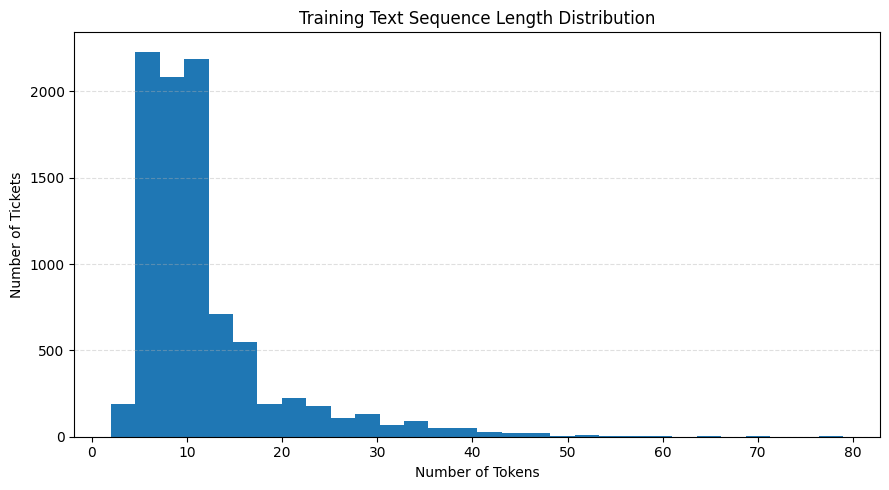

In [18]:
# Cell 16：训练集文本长度分布

import matplotlib.pyplot as plt


figure, axis = plt.subplots(
    figsize=(9, 5)
)

axis.hist(
    train_sequence_lengths,
    bins=30
)

axis.set_title(
    "Training Text Sequence Length Distribution"
)

axis.set_xlabel(
    "Number of Tokens"
)

axis.set_ylabel(
    "Number of Tickets"
)

axis.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [19]:
# Cell 17：设置最大序列长度

MAX_LENGTH = 50

PAD_ID = word_to_id[PAD_TOKEN]
UNK_ID = word_to_id[UNK_TOKEN]

print("MAX_LENGTH:", MAX_LENGTH)
print("PAD_ID:", PAD_ID)
print("UNK_ID:", UNK_ID)

MAX_LENGTH: 50
PAD_ID: 0
UNK_ID: 1


## Padding / Truncation

In [20]:
# Cell 18：Padding和Truncation

def pad_or_truncate(
    token_ids,
    max_length: int,
    pad_id: int
):
    """
    将token ID序列统一到固定长度。
    """

    # 太长：截断
    if len(token_ids) > max_length:
        token_ids = token_ids[:max_length]

    # 太短：补PAD
    elif len(token_ids) < max_length:

        padding_length = (
            max_length - len(token_ids)
        )

        token_ids = (
            token_ids
            + [pad_id] * padding_length
        )

    return token_ids

In [21]:
short_example = [5, 10, 20]

processed_example = pad_or_truncate(
    short_example,
    max_length=6,
    pad_id=PAD_ID
)

print(processed_example)

[5, 10, 20, 0, 0, 0]


In [22]:
# Cell 19：完整文本编码

def encode_and_pad_text(
    text: str,
    vocabulary: dict,
    max_length: int
):

    token_ids = encode_text(
        text,
        vocabulary
    )

    token_ids = pad_or_truncate(
        token_ids,
        max_length=max_length,
        pad_id=vocabulary[PAD_TOKEN]
    )

    return token_ids

In [23]:
sample_text = (
    "My transfer has not arrived yet"
)

sample_encoded = encode_and_pad_text(
    sample_text,
    word_to_id,
    MAX_LENGTH
)

print("序列长度：", len(sample_encoded))
print(sample_encoded)

序列长度： 50
[16, 89, 92, 27, 152, 151, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## ID映射

In [24]:
# Cell 20：建立类别ID映射

class_names = sorted(
    train_df["category"].unique()
)

label_to_id = {
    label: index
    for index, label
    in enumerate(class_names)
}

id_to_label = {
    index: label
    for label, index
    in label_to_id.items()
}

NUM_CLASSES = len(class_names)

print(
    "类别数量：",
    NUM_CLASSES
)

print()

for label in class_names[:10]:
    print(
        label,
        "→",
        label_to_id[label]
    )

类别数量： 77

Refund_not_showing_up → 0
activate_my_card → 1
age_limit → 2
apple_pay_or_google_pay → 3
atm_support → 4
automatic_top_up → 5
balance_not_updated_after_bank_transfer → 6
balance_not_updated_after_cheque_or_cash_deposit → 7
beneficiary_not_allowed → 8
cancel_transfer → 9


In [25]:
# Cell 21：确认训练/验证/测试类别一致

train_labels = set(
    train_df["category"].unique()
)

validation_labels = set(
    validation_df["category"].unique()
)

test_labels = set(
    test_df["category"].unique()
)

assert train_labels == validation_labels
assert train_labels == test_labels

print(
    "Train / Validation / Test标签完全一致。"
)

Train / Validation / Test标签完全一致。


## Dataset → DataLoader → batch

In [26]:
# Cell 22：导入Dataset和DataLoader

from torch.utils.data import Dataset, DataLoader

In [27]:
# Cell 23：定义BANKING77 Dataset

class Banking77Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        vocabulary,
        label_mapping,
        max_length
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.vocabulary = vocabulary
        self.label_mapping = label_mapping
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        text = row["text"]
        category = row["category"]

        # 文本编码
        input_ids = encode_and_pad_text(
            text=text,
            vocabulary=self.vocabulary,
            max_length=self.max_length
        )

        # 标签编码
        label_id = self.label_mapping[
            category
        ]

        # 转换成PyTorch Tensor
        input_ids = torch.tensor(
            input_ids,
            dtype=torch.long
        )

        label_id = torch.tensor(
            label_id,
            dtype=torch.long
        )

        return {
            "input_ids": input_ids,
            "label": label_id
        }

In [28]:
# Cell 24：创建Train / Validation / Test Dataset

train_dataset = Banking77Dataset(
    dataframe=train_df,
    vocabulary=word_to_id,
    label_mapping=label_to_id,
    max_length=MAX_LENGTH
)

validation_dataset = Banking77Dataset(
    dataframe=validation_df,
    vocabulary=word_to_id,
    label_mapping=label_to_id,
    max_length=MAX_LENGTH
)

test_dataset = Banking77Dataset(
    dataframe=test_df,
    vocabulary=word_to_id,
    label_mapping=label_to_id,
    max_length=MAX_LENGTH
)

print("Train dataset:", len(train_dataset))
print(
    "Validation dataset:",
    len(validation_dataset)
)
print("Test dataset:", len(test_dataset))

Train dataset: 9149
Validation dataset: 1961
Test dataset: 1961


In [29]:
# Cell 25：检查Dataset单条输出

sample = train_dataset[0]

print(
    "input_ids shape:",
    sample["input_ids"].shape
)

print(
    "label:",
    sample["label"]
)

print(
    "sequence length:",
    len(sample["input_ids"])
)

input_ids shape: torch.Size([50])
label: tensor(73)
sequence length: 50


In [30]:
sample_index = 0

print(
    "Original text:"
)

print(
    train_df.iloc[
        sample_index
    ]["text"]
)

print()

print(
    "Original category:"
)

print(
    train_df.iloc[
        sample_index
    ]["category"]
)

print()

print(
    "Encoded label:"
)

print(
    train_dataset[
        sample_index
    ]["label"].item()
)

Original text:
I want to get Visa and Mastercard

Original category:
visa_or_mastercard

Encoded label:
73


In [31]:
sample_label_id = (
    train_dataset[
        sample_index
    ]["label"].item()
)

print(
    "Decoded category:"
)

print(
    id_to_label[
        sample_label_id
    ]
)

Decoded category:
visa_or_mastercard


## Dataloader

In [32]:
# Cell 26：创建DataLoader

BATCH_SIZE = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 286
Validation batches: 62
Test batches: 62


In [33]:
# Cell 27：查看一个训练batch

batch = next(
    iter(train_loader)
)

print(
    "Batch input_ids shape:",
    batch["input_ids"].shape
)

print(
    "Batch labels shape:",
    batch["label"].shape
)

Batch input_ids shape: torch.Size([32, 50])
Batch labels shape: torch.Size([32])


In [34]:
print(
    batch["input_ids"][0]
)

print()

print(
    "Label ID:",
    batch["label"][0].item()
)

print(
    "Label name:",
    id_to_label[
        batch["label"][0].item()
    ]
)

tensor([ 82,  34,   2,   5,  16, 119, 109,   4, 251,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0])

Label ID: 47
Label name: pending_cash_withdrawal
